Import Panda to read the file

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

import matplotlib.pyplot as plt
import seaborn as sns
from calendar import month_name
from windrose import WindroseAxes

### Summary Statistics & Missing-Value Report

In [2]:
#read sierraleone file
df = pd.read_csv('../data/sierraleone-bumbuna.csv')
#take a look on the top sample data
df.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-30 00:01,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.1,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
1,2021-10-30 00:02,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2,2021-10-30 00:03,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
3,2021-10-30 00:04,-0.7,0.0,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.1,22.3,22.6,NaN
4,2021-10-30 00:05,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
GHI,525600.0,201.957515,298.495150,-19.5,-2.8,0.3,362.4,1499.0
DNI,525600.0,116.376337,218.652659,-7.8,-0.3,-0.1,107.0,946.0
DHI,525600.0,113.720571,158.946032,-17.9,-3.8,-0.1,224.7,892.0
ModA,525600.0,206.643095,300.896893,0.0,0.0,3.6,359.5,1507.0
ModB,525600.0,198.114691,288.889073,0.0,0.0,3.4,345.4,1473.0
Tamb,525600.0,26.319394,4.398605,12.3,23.1,25.3,29.4,39.9
RH,525600.0,79.448857,20.520775,9.9,68.7,85.4,96.7,100.0
WS,525600.0,1.146113,1.239248,0.0,0.0,0.8,2.0,19.2
WSgust,525600.0,1.691606,1.617053,0.0,0.0,1.6,2.6,23.9
WSstdev,525600.0,0.363823,0.295000,0.0,0.0,0.4,0.6,4.1


In [4]:
df.dtypes

Timestamp         object
GHI              float64
DNI              float64
DHI              float64
ModA             float64
ModB             float64
Tamb             float64
RH               float64
WS               float64
WSgust           float64
WSstdev          float64
WD               float64
WDstdev          float64
BP                 int64
Cleaning           int64
Precipitation    float64
TModA            float64
TModB            float64
Comments         float64
dtype: object

In [5]:
# Convert 'Timestamp' column to datetime format
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
# df.set_index('Timestamp', inplace=True)

In [6]:
# #check missing data value for each column 
missing_report = df.isna().sum().to_frame(name='Missing Count')
missing_report['Missing %'] = (df.isna().mean() * 100).round(2)
print(missing_report)


               Missing Count  Missing %
Timestamp                  0        0.0
GHI                        0        0.0
DNI                        0        0.0
DHI                        0        0.0
ModA                       0        0.0
ModB                       0        0.0
Tamb                       0        0.0
RH                         0        0.0
WS                         0        0.0
WSgust                     0        0.0
WSstdev                    0        0.0
WD                         0        0.0
WDstdev                    0        0.0
BP                         0        0.0
Cleaning                   0        0.0
Precipitation              0        0.0
TModA                      0        0.0
TModB                      0        0.0
Comments              525600      100.0


In [7]:

high_missing = missing_report[missing_report['Missing %'] > 5]
# print the columns with more than 5% missing values
print(high_missing)


          Missing Count  Missing %
Comments         525600      100.0


In [8]:
# eliminate column with above 5% of null data value
df = df.drop(columns=['Comments'])

In [9]:
print(df.columns)

Index(['Timestamp', 'GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS',
       'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation',
       'TModA', 'TModB'],
      dtype='object')


### Outlier Detection & Basic Cleaning

In [10]:

numeric_cols = df.select_dtypes(include='number').columns.tolist()
print(numeric_cols)


['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB']


In [11]:
Target_Column = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
print(Target_Column)

['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']


In [12]:
df[Target_Column].describe()

,GHI,DNI,DHI,ModA,ModB,WS,WSgust
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000
mean,201.957515,116.376337,113.720571,206.643095,198.114691,1.146113,1.691606
std,298.495150,218.652659,158.946032,300.896893,288.889073,1.239248,1.617053
min,-19.500000,-7.800000,-17.900000,0.000000,0.000000,0.000000,0.000000
25%,-2.800000,-0.300000,-3.800000,0.000000,0.000000,0.000000,0.000000
50%,0.300000,-0.100000,-0.100000,3.600000,3.400000,0.800000,1.600000
75%,362.400000,107.000000,224.700000,359.500000,345.400000,2.000000,2.600000
max,1499.000000,946.000000,892.000000,1507.000000,1473.000000,19.200000,23.900000


In [13]:
df[["GHI", "DNI" , "DHI"]] = df[["GHI", "DNI" , "DHI"]].clip(lower=0)
print("\nAfter fixing:")
print(df[["GHI", "DNI" , "DHI"]].describe())


After fixing:
                 GHI            DNI            DHI
count  525600.000000  525600.000000  525600.000000
mean      204.406778     116.523731     116.273677
std       296.787520     218.573992     157.020868
min         0.000000       0.000000       0.000000
25%         0.000000       0.000000       0.000000
50%         0.300000       0.000000       0.000000
75%       362.400000     107.000000     224.700000
max      1499.000000     946.000000     892.000000


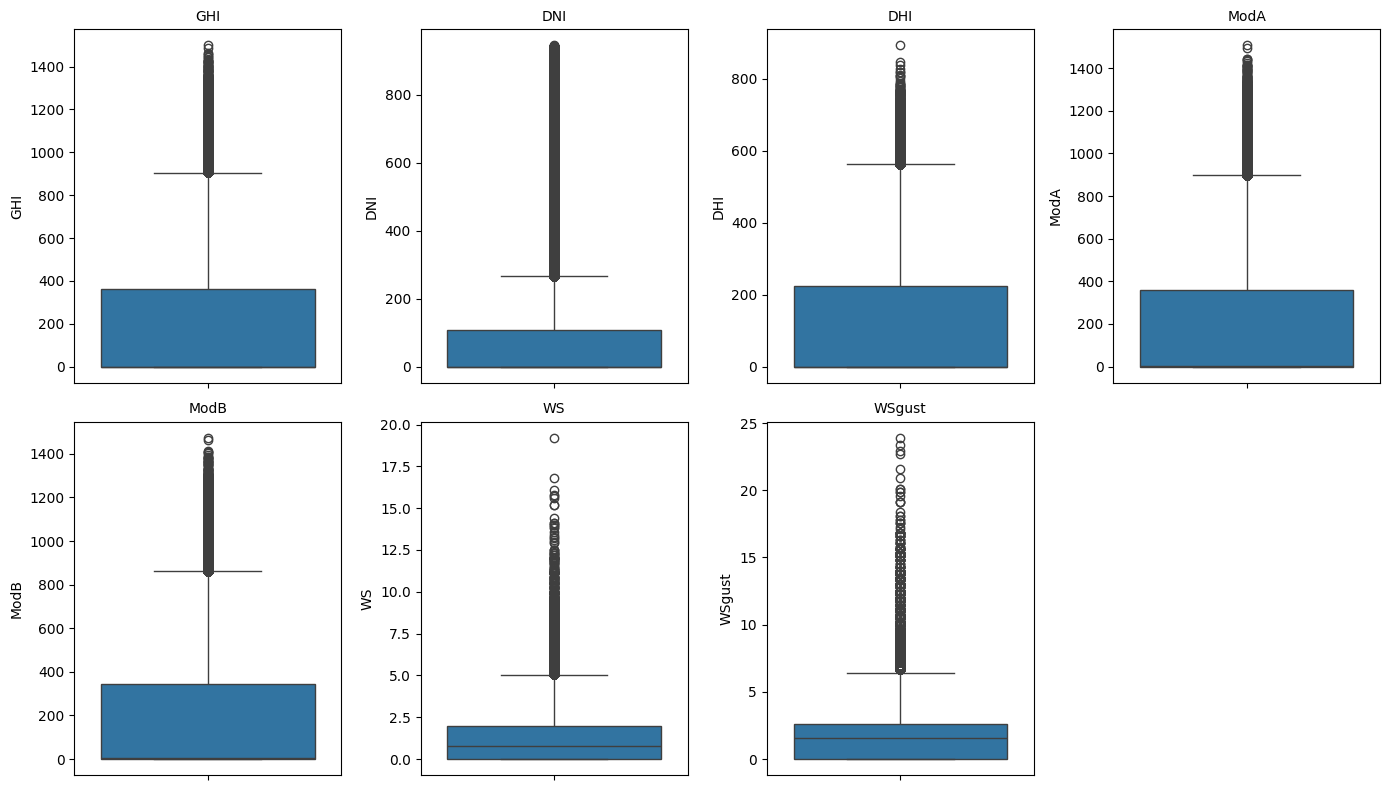

In [14]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(Target_Column):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col, fontsize=10)
plt.tight_layout()
plt.show()

In [15]:
# zscore to remove the outliers 

# Compute Z-scores
zscores = np.abs(zscore(df[Target_Column]))

# Mask for rows with all Z-scores <= 3 (i.e., no outliers)
no_outliers_mask = (zscores <= 3).all(axis=1)

# Apply the mask to get cleaned data
df_clean = df[no_outliers_mask]

# Compare before and after
print("Original rows:", df.shape[0])
print("Rows after outlier removal:", df_clean.shape[0])

Original rows: 525600
Rows after outlier removal: 509053


In [16]:
# Export cleaned data to CSV
df_clean.to_csv('../data/sierraleone-bumbuna_clean.csv', index=False)
print(f"Cleaned data saved")

Cleaned data saved


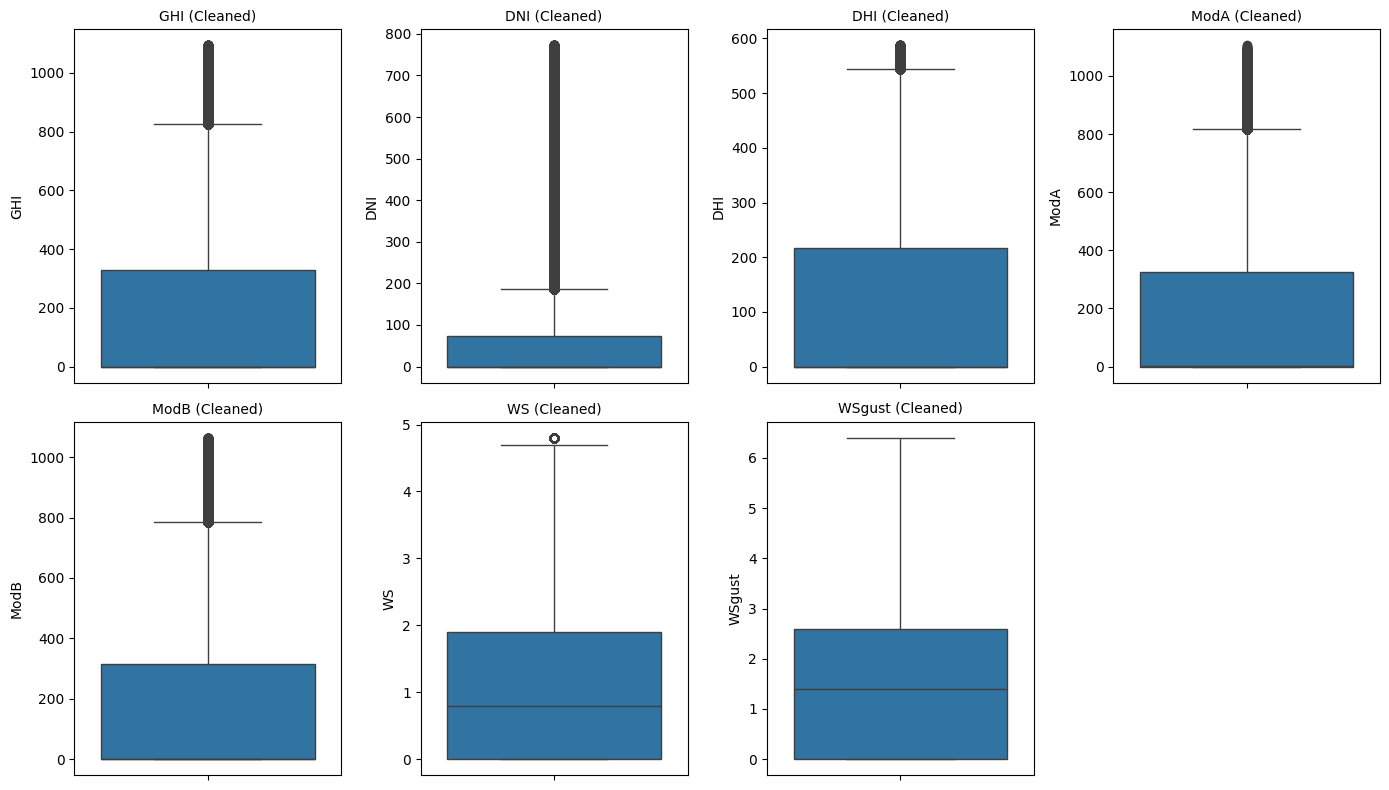

In [17]:
#box plot after cleanup 
plt.figure(figsize=(14, 8))
for i, col in enumerate(Target_Column):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(y=df_clean[col])
    plt.title(f"{col} (Cleaned)", fontsize=10)
plt.tight_layout()
plt.show()


### Time Series Analysis


In [18]:
# Sort by time
df = df_clean.sort_values('Timestamp')
# Set as index (makes time series plotting easier)
df.set_index('Timestamp', inplace=True)


<Figure size 1600x800 with 0 Axes>

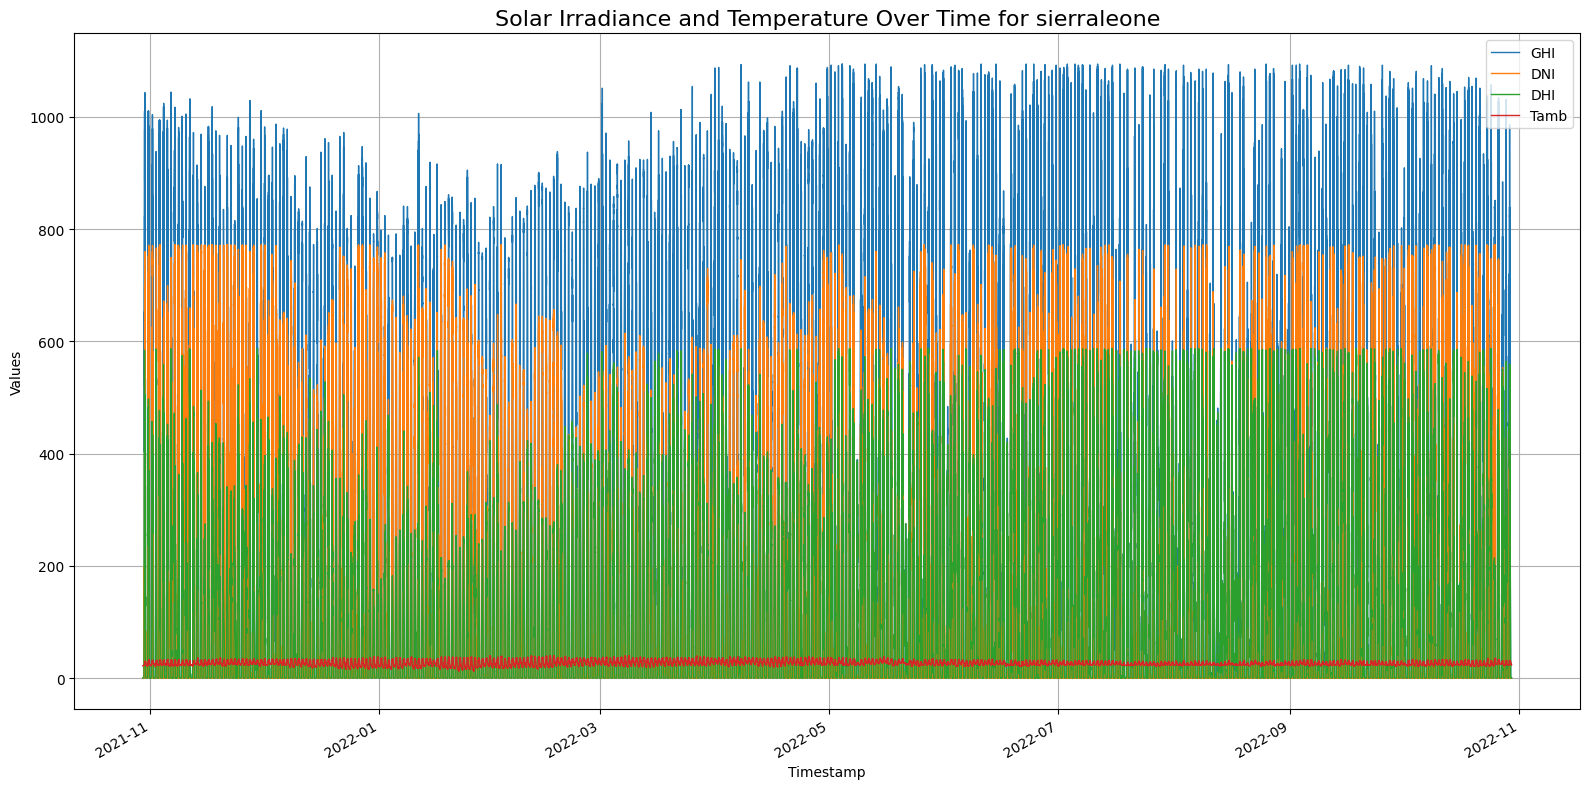

In [19]:
# Create a multi-line plot
plt.figure(figsize=(16, 8))

# Plot each variable
df[['GHI', 'DNI', 'DHI', 'Tamb']].plot(figsize=(16, 8), linewidth=1)

plt.title("Solar Irradiance and Temperature Over Time for sierraleone", fontsize=16)
plt.ylabel("Values")
plt.xlabel("Timestamp")
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

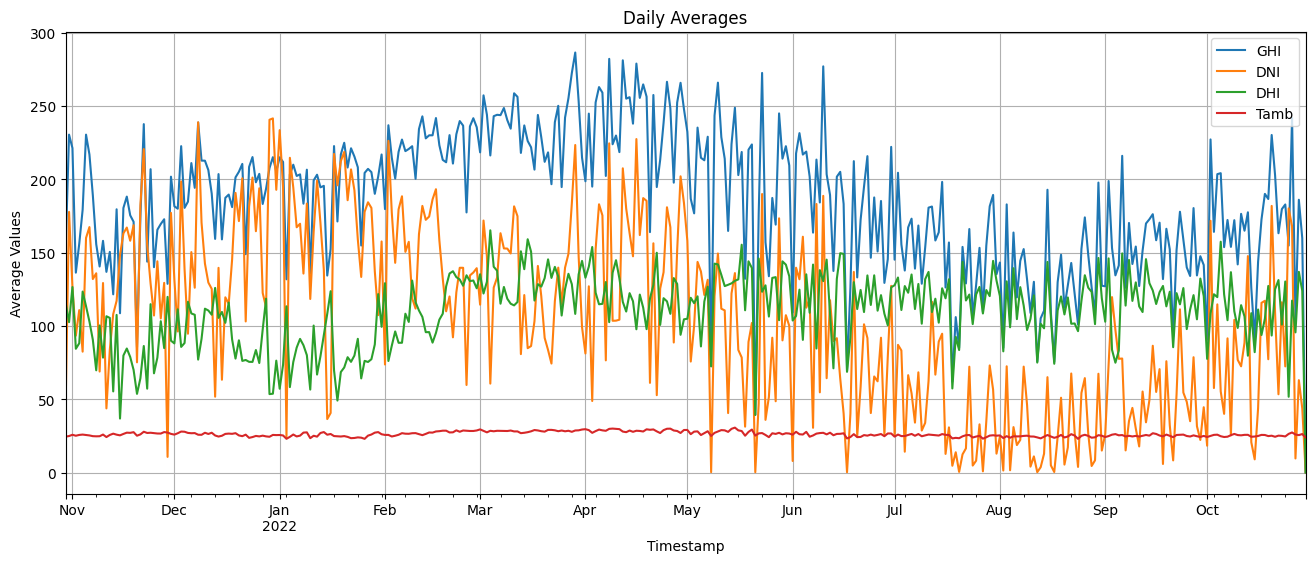

In [20]:
# Daily average plot
df_daily = df[['GHI', 'DNI', 'DHI', 'Tamb']].resample('D').mean()

df_daily.plot(figsize=(16, 6), title='Daily Averages')
plt.ylabel('Average Values')
plt.grid(True)
plt.show()

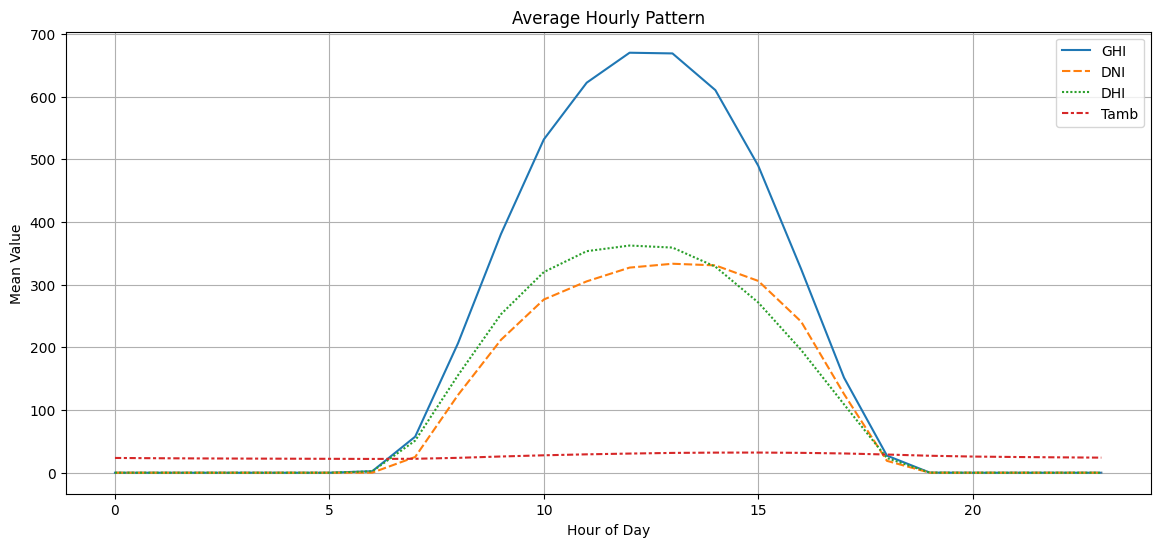

In [21]:
# Add hour column to see how things change throughout the day
df['hour'] = df.index.hour

# Plot average values per hour
plt.figure(figsize=(14, 6))
sns.lineplot(data=df.groupby('hour')[['GHI', 'DNI', 'DHI', 'Tamb']].mean())
plt.title('Average Hourly Pattern')
plt.ylabel('Mean Value')
plt.xlabel('Hour of Day')
plt.grid(True)
plt.show()

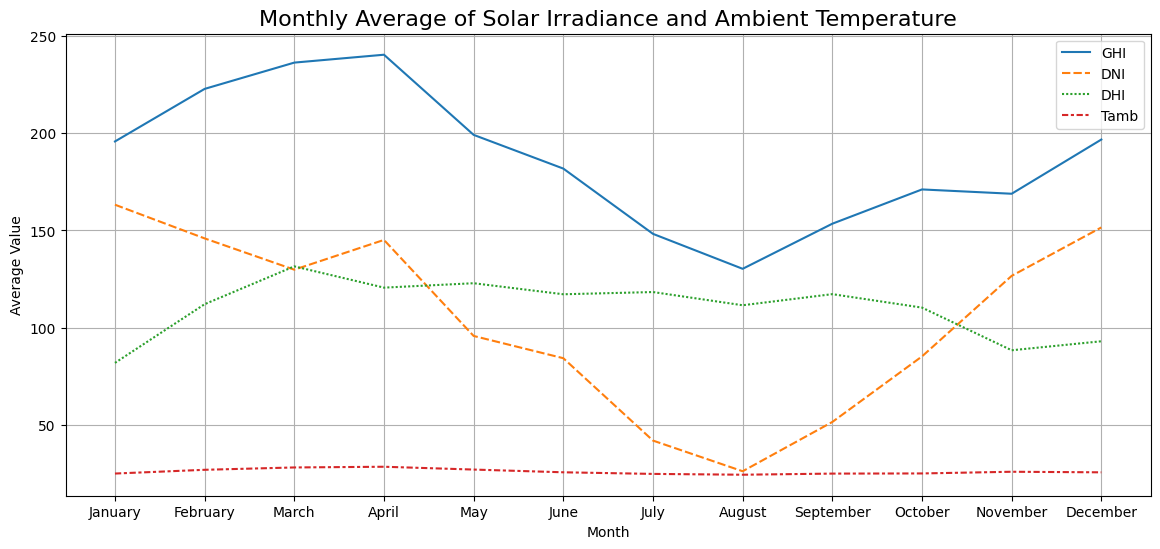

In [22]:
# Extract month names from the DatetimeIndex
df['Month'] = df.index.month_name()

# Group by month name and compute the mean for each variable
monthly_avg = df.groupby('Month')[['GHI', 'DNI', 'DHI', 'Tamb']].mean()

# Ensure months are in calendar order
month_order = list(month_name)[1:]  # Skips the empty string at index 0
monthly_avg = monthly_avg.reindex(month_order)

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_avg)
plt.title("Monthly Average of Solar Irradiance and Ambient Temperature", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Average Value")
plt.grid(True)
plt.show()


### Cleaning Impact


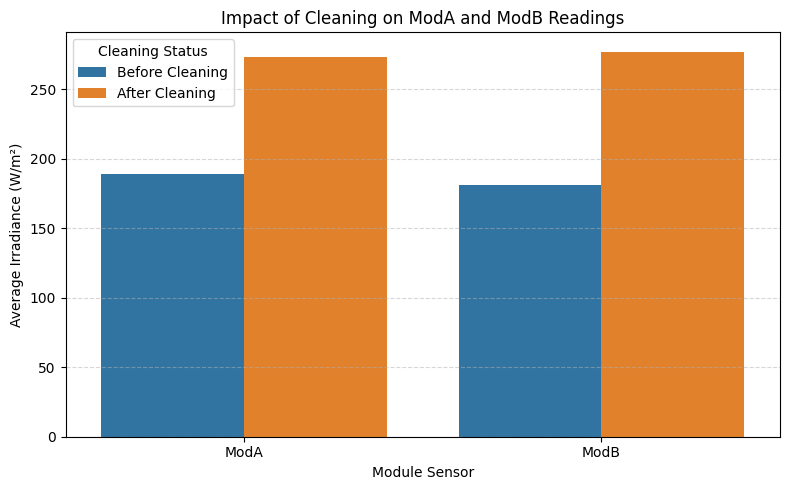

In [23]:
# Group by Cleaning status (0 = no cleaning, 1 = cleaned)
cleaning_impact = df.groupby('Cleaning')[['ModA', 'ModB']].mean()

# Reset index for plotting
cleaning_impact = cleaning_impact.reset_index()
cleaning_impact['Cleaning'] = cleaning_impact['Cleaning'].map({0: 'Before Cleaning', 1: 'After Cleaning'})

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(data=cleaning_impact.melt(id_vars='Cleaning', value_vars=['ModA', 'ModB']),
            x='variable', y='value', hue='Cleaning')

plt.title('Impact of Cleaning on ModA and ModB Readings')
plt.ylabel('Average Irradiance (W/m²)')
plt.xlabel('Module Sensor')
plt.legend(title='Cleaning Status')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Correlation & Relationship Analysis


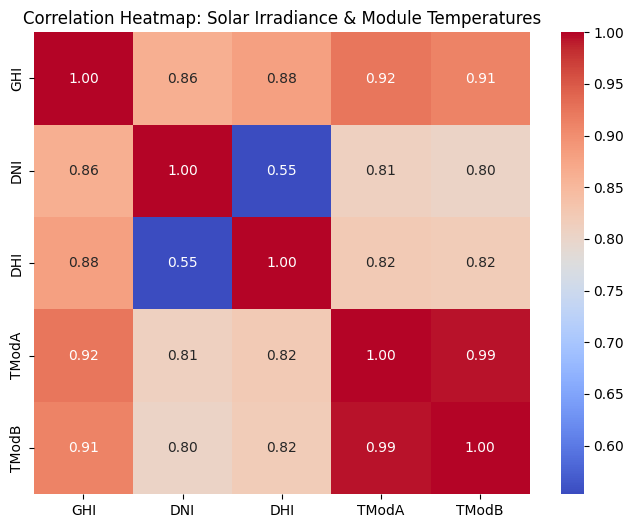

In [24]:
# Select columns for correlation heatmap
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']
corr_matrix = df[corr_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Solar Irradiance & Module Temperatures")
plt.show()

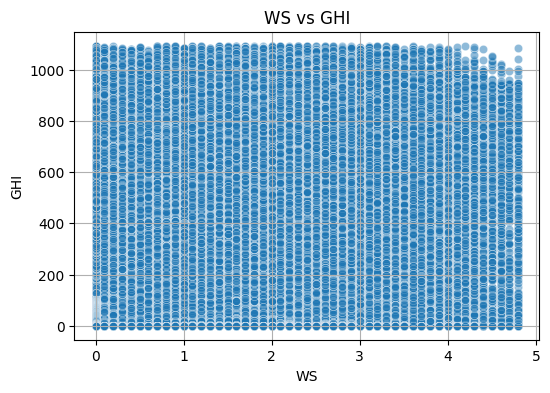

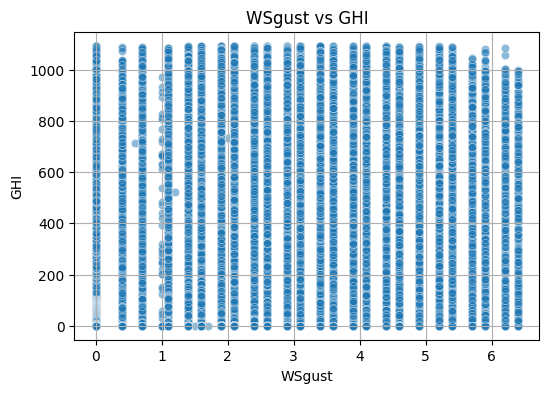

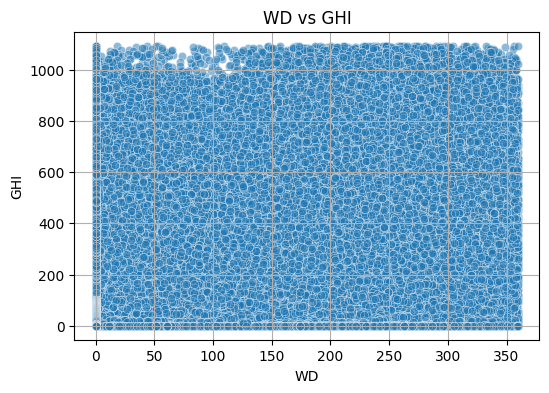

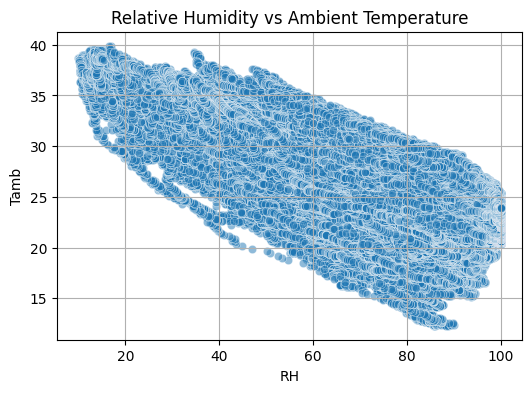

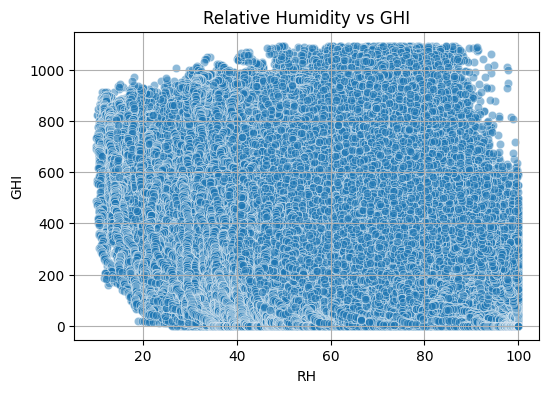

In [25]:
# WS, WSgust, WD vs. GHI
scatter_vars = ['WS', 'WSgust', 'WD']
for var in scatter_vars:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=var, y='GHI', alpha=0.5)
    plt.title(f'{var} vs GHI')
    plt.grid(True)
    plt.show()

# RH vs Tamb
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='RH', y='Tamb', alpha=0.5)
plt.title('Relative Humidity vs Ambient Temperature')
plt.grid(True)
plt.show()

# RH vs GHI
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='RH', y='GHI', alpha=0.5)
plt.title('Relative Humidity vs GHI')
plt.grid(True)
plt.show()

### Wind & Distribution Analysis

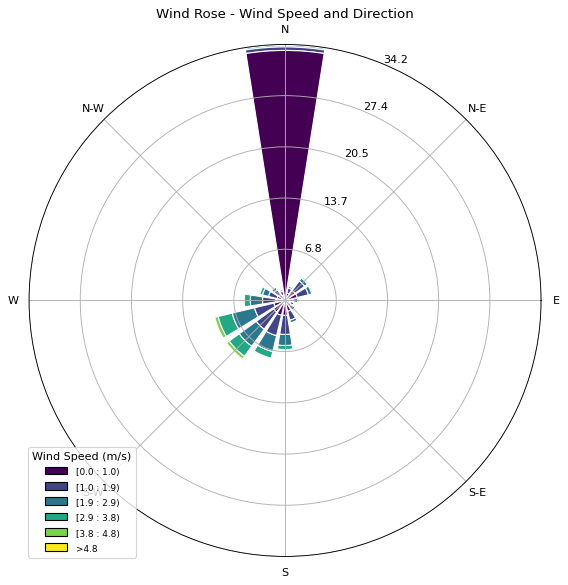

In [27]:
# Drop NA values for WS and WD
wind_data = df[['WS', 'WD']].dropna()

# Create wind rose
ax = WindroseAxes.from_ax()
ax.bar(wind_data['WD'], wind_data['WS'], normed=True, opening=0.8, edgecolor='white')
ax.set_legend(title="Wind Speed (m/s)")
plt.title("Wind Rose - Wind Speed and Direction")
plt.show()

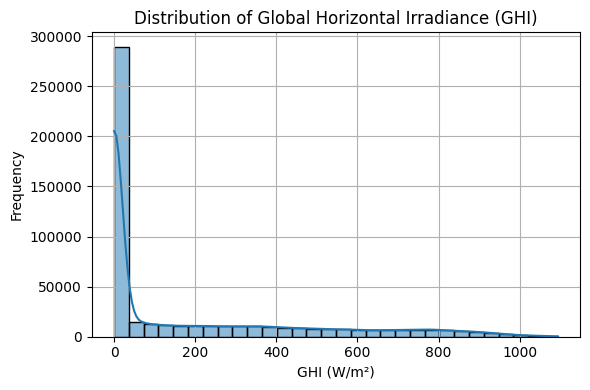

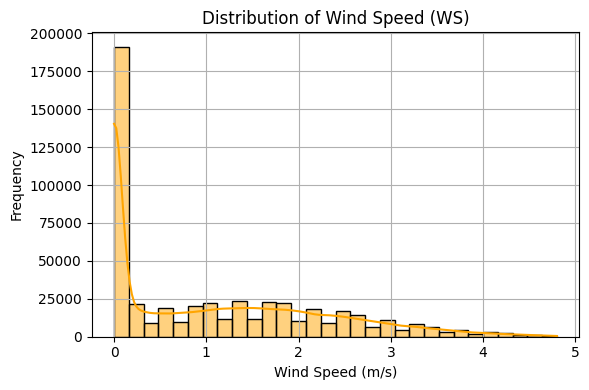

In [28]:
# Histogram for GHI
plt.figure(figsize=(6, 4))
sns.histplot(df['GHI'].dropna(), bins=30, kde=True)
plt.title("Distribution of Global Horizontal Irradiance (GHI)")
plt.xlabel("GHI (W/m²)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

# Histogram for Wind Speed (WS)
plt.figure(figsize=(6, 4))
sns.histplot(df['WS'].dropna(), bins=30, kde=True, color='orange')
plt.title("Distribution of Wind Speed (WS)")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


### Temperature Analysis


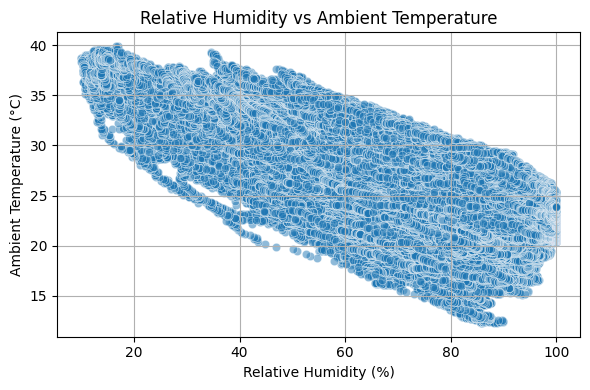

In [29]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='RH', y='Tamb', alpha=0.5)
plt.title("Relative Humidity vs Ambient Temperature")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Ambient Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

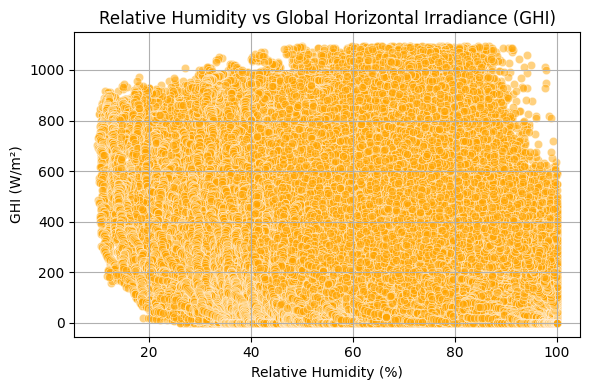

In [30]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='RH', y='GHI', alpha=0.5, color='orange')
plt.title("Relative Humidity vs Global Horizontal Irradiance (GHI)")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("GHI (W/m²)")
plt.grid(True)
plt.tight_layout()
plt.show()


### Bubble Chart


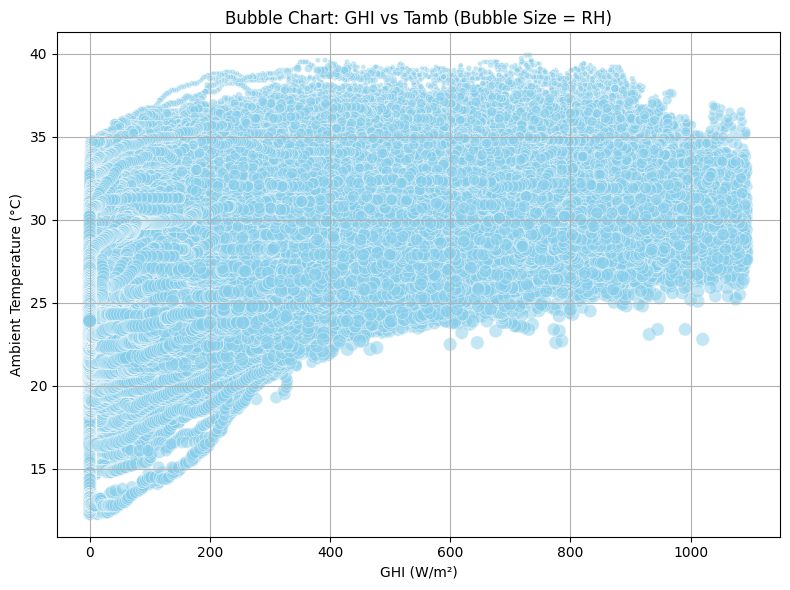

In [31]:
# Drop rows with missing values in relevant columns
bubble_df = df[['GHI', 'Tamb', 'RH']].dropna()

plt.figure(figsize=(8, 6))
plt.scatter(
    bubble_df['GHI'],        # X-axis
    bubble_df['Tamb'],       # Y-axis
    s=bubble_df['RH'],       # Bubble size
    alpha=0.5,
    c='skyblue',
    edgecolors='w',
    linewidths=0.5
)

plt.title("Bubble Chart: GHI vs Tamb (Bubble Size = RH)")
plt.xlabel("GHI (W/m²)")
plt.ylabel("Ambient Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()